# Análisis de regresión simple

Vamos a predecir la variable Sepal Length a partir de las demas variables.

#### Bibliotecas necesarias

In [1]:
#General
import numpy as np
import pandas as pd
from skimpy import skim

#Estadisticas
from scipy import stats

#Graficas
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pandas.plotting import andrews_curves


#Valores ausentes
from pyod.models.mcd import MCD

#Modelo de regresion 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

## Carga de datos

In [2]:
df = pd.read_csv(r"C:\Users\raulb\Desktop\Diplomado\Modulo2\Datos\iris.csv")

In [3]:
df.sample(10)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
26,5.0,3.4,1.6,0.4,setosa
37,4.9,3.6,1.4,0.1,setosa
93,5.0,2.3,3.3,1.0,versicolor
101,5.8,2.7,5.1,1.9,virginica
29,4.7,3.2,1.6,0.2,setosa
48,5.3,3.7,1.5,0.2,setosa
23,5.1,3.3,1.7,0.5,setosa
43,5.0,3.5,1.6,0.6,setosa
0,5.1,3.5,1.4,0.2,setosa
55,5.7,2.8,4.5,1.3,versicolor


In [4]:
#Transformamos en categorica
df["Species"] = df["Species"].astype("category")

In [5]:
#Breve resumen
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 150    │ │ float64     │ 4     │ │ Species               │                                │
│ │ Number of columns │ 5      │ │ category    │ 1     │ └───────────────────────┘                                │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column            ┃ NA   ┃ NA %   ┃ mean     ┃ sd        ┃ p0    ┃ p25   ┃ p50    ┃ p75  ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ Sepal.Length      │    0 │      0 │    5.843 │    0.8281 │   4.3 │   5.1 │    5.8 │  6.4 │   7.9 │ ▃▇▇▇▅▂  │  │
│ │ Sepal.Width       │    0 │      0 │    3.057 │    0.4359 │     2 │   2.8 │      3 │  3.3 │   4.4 │ ▁▇▇▇▂▁  │  │
│ │ Petal.Length      │    0 │      0 │    3.758 │     1.765 │     1 │   1.6 │   4.35 │  5.1 │   6.9 │ ▇ ▂▇▆▂  │  │
│ │ Petal.Width       │    0 │      0 │    1.199 │    0.7622 │   0.1 │   0.3 │    1.3 │  1.8 │   2.5 │ ▇ ▂▆▅▃  │  │
│ └───────────────────┴──────┴────────┴──────────┴───────────┴───────┴───────┴────────┴──────┴───────┴─────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                   ┃ NA         ┃ NA %             ┃ ordered                  ┃ unique               ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Species                  │          0 │                0 │ False                    │                    3 │  │
│ └──────────────────────────┴────────────┴──────────────────┴──────────────────────────┴──────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

De lo anterior vemos que no existen valores ausentes.

## Analisis Exploratorio

In [6]:
var_cat = ["Species"]
var_num = list(set(df.columns) - set(var_cat))

In [7]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#008080"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#00a77d", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values, textinfo='percent+label')]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self):
        corr_matrix = self.df[self.num_vars].corr()

        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='Viridis'))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [8]:
#Curva de Andrews
def andrews_curve(df, cat_col): 
    plt.figure(figsize=(12,8))
    andrews_curves(df, cat_col, colormap='rainbow', alpha=0.6)
    plt.title('Curvas de Andrews')
    plt.xlabel('t (función de Fourier)')
    plt.ylabel('Valor transformado')
    plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
    plt.show()

In [9]:
analisis = analyze(df, var_num, var_cat)

In [10]:
analisis.plot_num()

In [11]:
analisis.plot_cat()

In [12]:
analisis.corr_matrix()

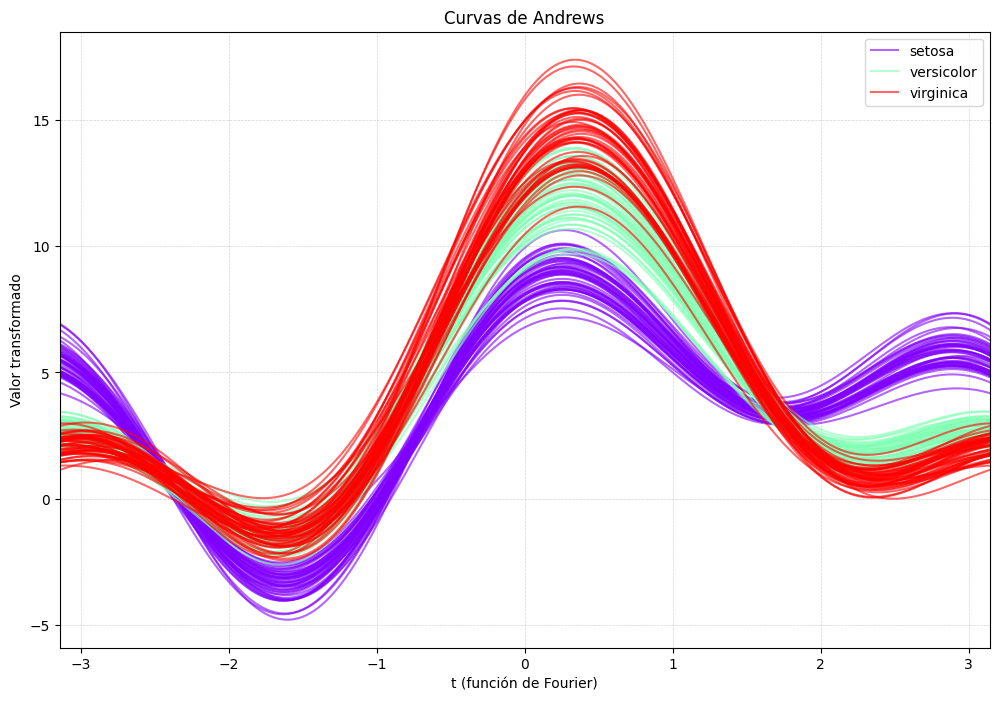

In [13]:
andrews_curve(df, "Species")

In [ ]:
def plot_by_cat(df, var_num, var_cat):
    for var in var_num:
        fig, axes = plt.subplots(1, 2, figsize=(12,5))
        
        # Boxplot
        sns.boxplot(x=var_cat, y=var, data=df, ax=axes[0], palette="Set2")
        axes[0].set_title(f"{var}")
        axes[0].tick_params(axis='x', rotation=45)
        
        # Densidad
        sns.kdeplot(data=df, x=var, hue=var_cat, fill=True, alpha=0.4, ax=axes[1])
        axes[1].set_title(f"{var}")
        
        plt.tight_layout()
        plt.show()

C:\Users\raulb\AppData\Local\Temp\ipykernel_7080\306149544.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




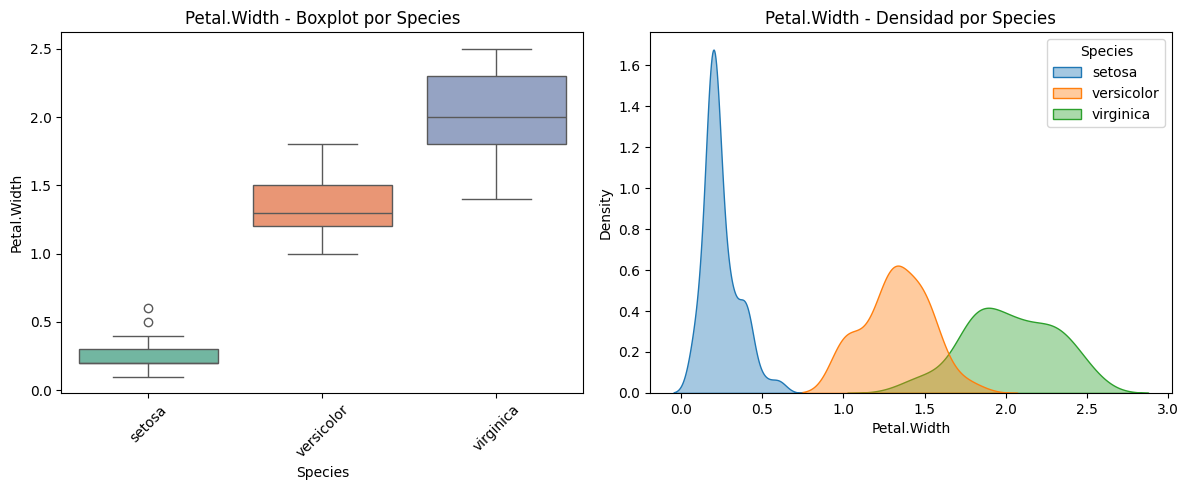

C:\Users\raulb\AppData\Local\Temp\ipykernel_7080\306149544.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




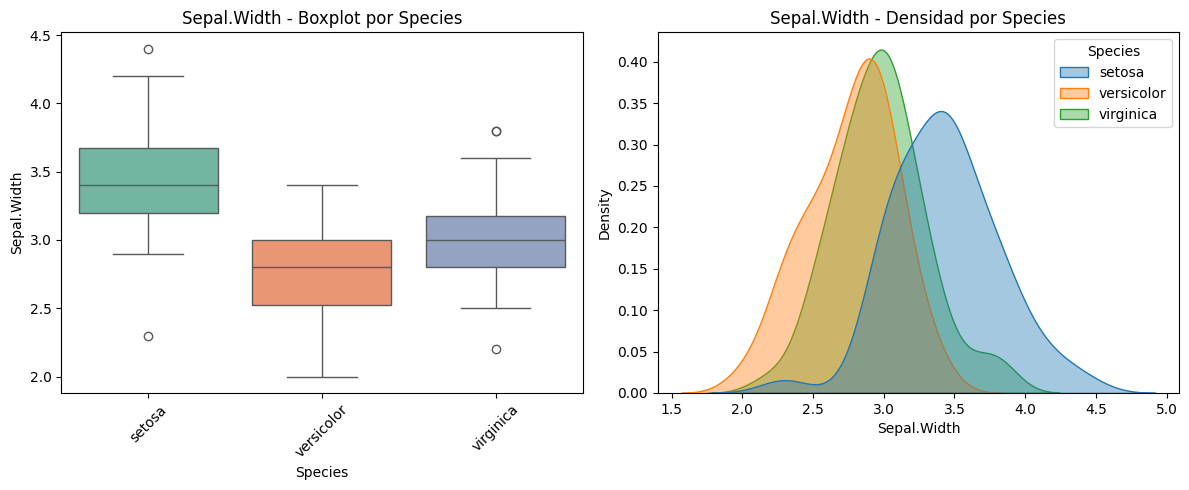

C:\Users\raulb\AppData\Local\Temp\ipykernel_7080\306149544.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




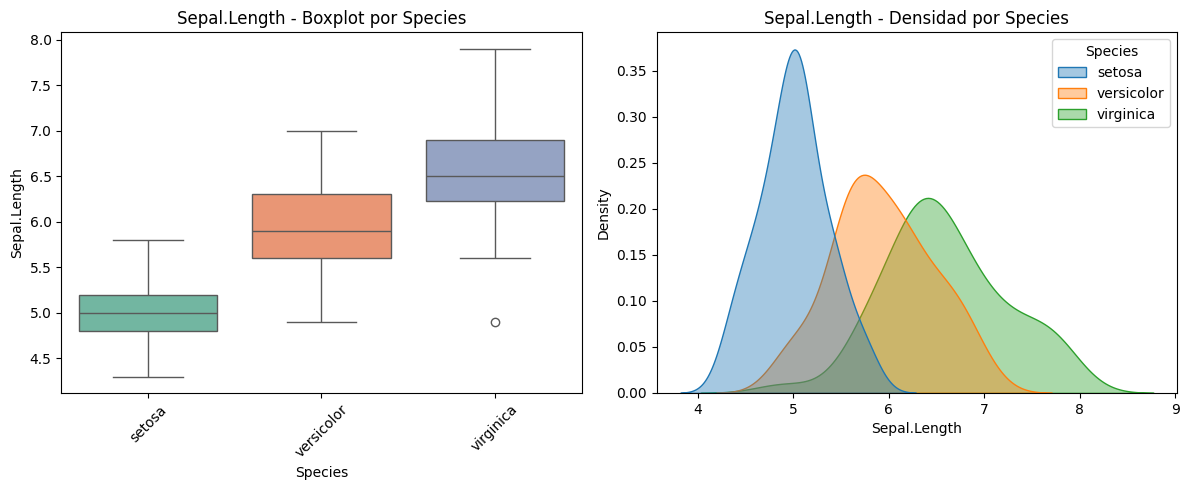

C:\Users\raulb\AppData\Local\Temp\ipykernel_7080\306149544.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




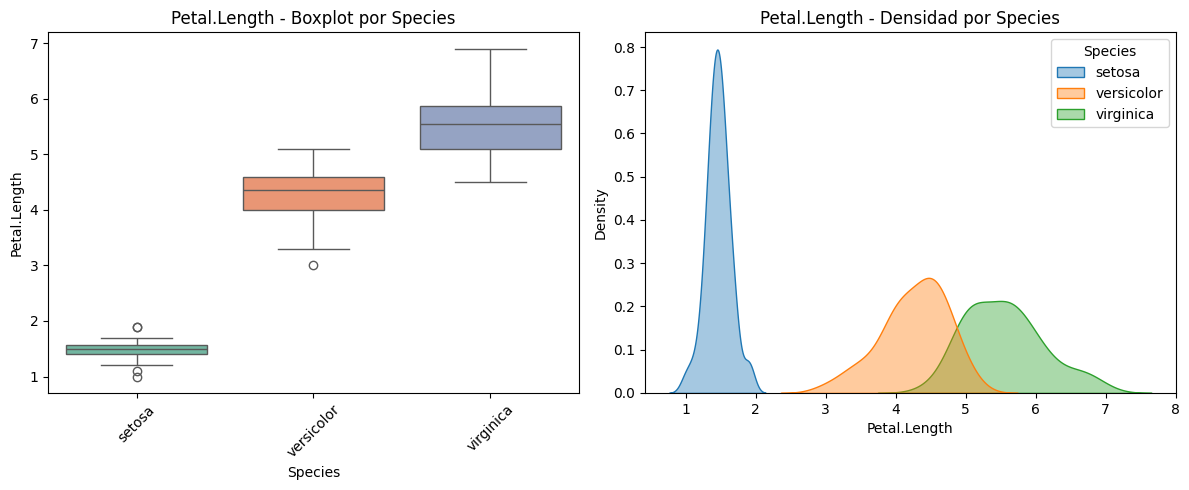

In [15]:
plot_by_cat(df, var_num, "Species")

### Valores atipicos

In [16]:
#Usaremos minima covarianza
def outliers_mcd(df, contamination=0.05, random_state=1989, support_fraction=None):
    model = MCD(contamination=contamination, random_state=random_state, support_fraction=support_fraction)
    model.fit(df)
    preds = model.predict(df)
    return df[preds == 1]  #detectar

In [17]:
df_outliers = outliers_mcd(df[var_num])

In [18]:
df_outliers

,Petal.Width,Sepal.Width,Sepal.Length,Petal.Length
41,0.3,2.3,4.5,1.3
107,1.8,2.9,7.3,6.3
114,2.4,2.8,5.8,5.1
117,2.2,3.8,7.7,6.7
122,2.0,2.8,7.7,6.7
131,2.0,3.8,7.9,6.4
134,1.4,2.6,6.1,5.6
141,2.3,3.1,6.9,5.1


In [19]:
#Visualizamos en el df original
df.loc[df_outliers.index]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
41,4.5,2.3,1.3,0.3,setosa
107,7.3,2.9,6.3,1.8,virginica
114,5.8,2.8,5.1,2.4,virginica
117,7.7,3.8,6.7,2.2,virginica
122,7.7,2.8,6.7,2.0,virginica
131,7.9,3.8,6.4,2.0,virginica
134,6.1,2.6,5.6,1.4,virginica
141,6.9,3.1,5.1,2.3,virginica


De lo anterior podemos decir lo siguiente: 

* Hay fuerte correlación entre longitud y ancho del petalo. 
* Hay una gran diferencia entre Setosa y los otros dos grupos, los cuales se mezclan un poco mas.
* Hay valores atipicos que pertenecen en su mayoria a virginica, pero no los quitaremos al tener muy pocos datos y no parecer tan alejados.

## Modelado

### Train/test split, codificacion, escalamiento

In [20]:
y = df["Sepal.Length"]
X = df.drop(columns=["Sepal.Length"])

In [21]:
X = pd.get_dummies(X, columns=["Species"], drop_first=True)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1989)

In [23]:
X_train01 = X_train.copy()

In [24]:
num_vars = ["Sepal.Width", "Sepal.Width", "Petal.Width"]

scaler = MinMaxScaler()

#Ajustamos solo con train
scaler.fit(X_train)

#Transformar train y test
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])


In [25]:
X_train

,Sepal.Width,Petal.Length,Petal.Width,Species_versicolor,Species_virginica
103,0.375000,5.6,0.708333,False,True
84,0.416667,4.5,0.583333,True,False
63,0.375000,4.7,0.541667,True,False
101,0.291667,5.1,0.750000,False,True
100,0.541667,6.0,1.000000,False,True
...,...,...,...,...,...
79,0.250000,3.5,0.375000,True,False
37,0.666667,1.4,0.000000,False,False
60,0.000000,3.5,0.375000,True,False
119,0.083333,5.0,0.583333,False,True


### Regresion Lineal Ordinaria

In [26]:
class Regresion:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        
        self.model = None
        self.y_fitted = None
        self.y_pred = None

    #Ajustamos el modelo
    def fit_reg(self):
        self.model = LinearRegression(fit_intercept=True)
        self.model.fit(self.X_train, self.y_train)
        
        #Calculamos predicciones
        self.y_fitted = self.model.predict(self.X_train)
        self.y_pred = self.model.predict(self.X_test)
        return self.model

    #DataFrame con valores observados, ajustados/predichos y residuales
    def fitted_values(self, dataset="train"):
        if dataset == "train":
            df = pd.DataFrame({
                "Observed": self.y_train,
                "Fitted": self.y_fitted,
                "Residual": self.y_train - self.y_fitted
            })
        elif dataset == "test":
            df = pd.DataFrame({
                "Observed": self.y_test,
                "Predicted": self.y_pred,
                "Residual": self.y_test - self.y_pred
            })
        else:
            raise ValueError("dataset debe ser 'train' o 'test'")
        return df

    #Coeficientes del modelo
    def coefs(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
            
        cfs = [self.model.intercept_]
        cfs.extend(list(self.model.coef_))
        coef_names = ["intercept"] + list(self.X_train.columns)

        dt = {"Vars": coef_names, "Coefs": cfs}
        return pd.DataFrame(dt)

    #Validacion cruzada
    def cross_values(self, cv=4):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
        
        cv_score = cross_val_score(
            estimator=self.model,
            X=self.X_train,
            y=self.y_train,
            cv=cv,
            n_jobs=-1,
            scoring="r2"
        )
        cv_values = {
            "media": np.round(np.mean(cv_score),4),
            "mediana": np.round(np.median(cv_score),4),
            "desv. est": np.round(np.std(cv_score, ddof=1),4)
        }
        return cv_values

    #Metricas de desempeño
    def performance(self):
        if self.y_fitted is None or self.y_pred is None:
            raise ValueError("Primero ajusta el modelo con fit_reg() para calcular predicciones")
        
        r2_train = np.round(r2_score(self.y_train, self.y_fitted), 4)
        r2_test  = np.round(r2_score(self.y_test, self.y_pred), 4)

        rmse_train = np.round(root_mean_squared_error(self.y_train, self.y_fitted), 4)
        rmse_test  = np.round(root_mean_squared_error(self.y_test, self.y_pred), 4)

        mae_train = np.round(mean_absolute_error(self.y_train, self.y_fitted), 4)
        mae_test  = np.round(mean_absolute_error(self.y_test, self.y_pred), 4)

        mape_train = np.round(mean_absolute_percentage_error(self.y_train, self.y_fitted), 4)
        mape_test  = np.round(mean_absolute_percentage_error(self.y_test, self.y_pred), 4)

        perform = {
            "Metrica": [
                "R2_train", "R2_test",
                "rmse_train", "rmse_test",
                "mae_train", "mae_test",
                "mape_train", "mape_test"
            ],
            "Valor": [
                r2_train, r2_test,
                rmse_train, rmse_test,
                mae_train, mae_test,
                mape_train, mape_test
            ]
        }
        return pd.DataFrame(perform)

In [27]:
#Instanciamos el modelo
lmodel = Regresion(X_train, X_test, y_train, y_test)

In [28]:
#Entrenamos y ajustamos
lmodel.fit_reg()

LinearRegression()

In [29]:
#Valores ajustados
lmodel.fitted_values("train")

,Observed,Fitted,Residual
103,6.3,6.678669,-0.378669
84,5.4,6.174703,-0.774703
63,6.1,6.340934,-0.240934
101,5.8,6.105432,-0.305432
100,6.3,6.864902,-0.564902
...,...,...,...
79,5.7,5.384671,0.315329
37,4.9,5.117789,-0.217789
60,5.0,5.072616,-0.072616
119,6.0,5.965408,0.034592


In [30]:
lmodel.fitted_values("test").head(10)

,Observed,Predicted,Residual
121,5.6,5.939201,-0.339201
59,5.2,5.567638,-0.367638
105,7.6,7.414515,0.185485
89,5.5,5.598200,-0.098200
10,5.4,5.202537,0.197463
1,4.9,4.754813,0.145187
78,6.0,6.122694,-0.122694
146,6.3,5.917754,0.382246
47,4.6,4.858832,-0.258832
88,5.6,5.941905,-0.341905


In [31]:
#Coeficientes del modelo
lmodel.coefs()

,Vars,Coefs
0,intercept,3.114406
1,Sepal.Width,1.248219
2,Petal.Length,0.836598
3,Petal.Width,-1.222089
4,Species_versicolor,-0.511598
5,Species_virginica,-0.723119


In [32]:
#Validación cruzada
lmodel.cross_values()

{'media': np.float64(0.8128),
 'mediana': np.float64(0.8058),
 'desv. est': np.float64(0.0626)}

In [33]:
#Performance 
lmodel.performance()

,Metrica,Valor
0,R2_train,0.8598
1,R2_test,0.8746
2,rmse_train,0.2956
3,rmse_test,0.3198
4,mae_train,0.2380
5,mae_test,0.2613
6,mape_train,0.0413
7,mape_test,0.0440


In [34]:
#COeficientes
coef_tab = lmodel.coefs()

In [35]:
coef_tab

,Vars,Coefs
0,intercept,3.114406
1,Sepal.Width,1.248219
2,Petal.Length,0.836598
3,Petal.Width,-1.222089
4,Species_versicolor,-0.511598
5,Species_virginica,-0.723119


In [36]:
def coef_original(df_coef, X_train, num_vars=None):
    #Si no se pasan num_vars, tomamos las numéricas de X_train
    if num_vars is None:
        num_vars = X_train.select_dtypes(include=np.number).columns.tolist()
    
    # Calculamos rango original
    original_ranges = {var: X_train[var].max() - X_train[var].min() for var in num_vars}

    # Creamos columna desescalada
    descaled = []
    for var, coef in zip(df_coef["Vars"], df_coef["Coefs"]):
        if var in original_ranges:
            descaled.append(coef / original_ranges[var])
        else:
            descaled.append(coef)  # Intercept y variables categóricas
    
    df_coef = df_coef.copy()
    df_coef["Coef_OriginalScale"] = descaled
    
    # Opcional: establecer 'Vars' como índice
    df_coef.set_index("Vars", inplace=True)
    
    return df_coef

In [37]:
coef_original(coef_tab, X_train01, num_vars = ["Sepal.Width", "Petal.Width", "Petal.Length"])

,Coefs,Coef_OriginalScale
Vars,,
intercept,3.114406,3.114406
Sepal.Width,1.248219,0.520091
Petal.Length,0.836598,0.141796
Petal.Width,-1.222089,-0.509204
Species_versicolor,-0.511598,-0.511598
Species_virginica,-0.723119,-0.723119
